In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent 
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import matplotlib.pyplot as plt
from phase_model.segmenter import FourierVisionConfig, FourierVisionSegmenter
from synthetic import (
    MovingObject,
    generate_synthetic_sequence,
)

plt.rcParams["font.family"] = "Times New Roman"

In [3]:
objects = [
    MovingObject("gaussian", center=(32, 32), velocity=(-1.5, -0.7), size=5.0)
]

video, _, meta = generate_synthetic_sequence(
    T=8, H=64, W=64,
    objects=objects,
    noise_std=0.0,
    clip=False,
)

cfg = FourierVisionConfig(
    velocity_bounds=[-2,2],
    num_components=1,
    num_velocities=1,
    solver="prony",
)

result = FourierVisionSegmenter(cfg).detect(video)
print("GT:", meta["velocities"])
print("Estimated:", result.velocities)

GT: [(-1.5, -0.7)]
Estimated: [(-1.5, -0.7)]


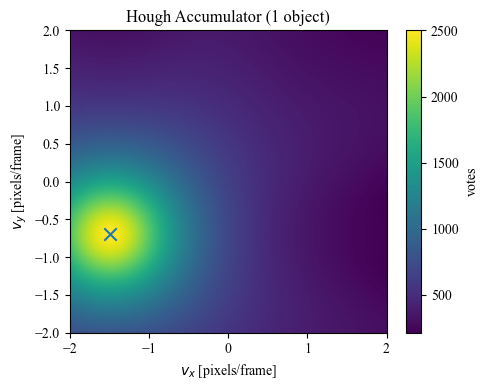

In [4]:
plt.figure(figsize=(5, 4))

plt.imshow(
    result.hough,
    origin="lower",
    extent=[
        result.vx_values[0],
        result.vx_values[-1],
        result.vy_values[0],
        result.vy_values[-1],
    ],
    aspect="auto",
)

plt.xlabel(r"$v_x$ [pixels/frame]")
plt.ylabel(r"$v_y$ [pixels/frame]")
plt.title("Hough Accumulator (1 object)")
plt.colorbar(label="votes")

# Optional: mark detected velocities
for vx, vy in result.velocities:
    plt.scatter(vx, vy, marker="x", s=80)

plt.tight_layout()
plt.show()

In [5]:
objects = [
    MovingObject("gaussian", (20, 32), (1.0, 0.0), 5.0),
    MovingObject("gaussian", (44, 32), (-1.0, 0.5), 6.0),
]

video, _, meta = generate_synthetic_sequence(
    T=6, H=64, W=64,
    objects=objects,
    noise_std=0.0,
    clip=False,
)

In [6]:
cfg_closed = FourierVisionConfig(
    velocity_bounds=[-2,2],
    solver="closed_form_m2",
    num_components=2,
    num_velocities=2,
    peak_min_separation=25,
)

res_closed = FourierVisionSegmenter(cfg_closed).detect(video)

In [7]:
cfg_prony = FourierVisionConfig(
    velocity_bounds=[-2,2],
    solver="prony",
    num_components=2,
    num_velocities=2,
    peak_min_separation=25,
)

res_prony = FourierVisionSegmenter(cfg_prony).detect(video)

In [8]:
print("GT:", meta["velocities"])
print("Closed:", res_closed.velocities)
print("Prony:", res_prony.velocities)

GT: [(1.0, 0.0), (-1.0, 0.5)]
Closed: [(0.96, 0.0), (-0.9199999999999999, 0.5)]
Prony: [(0.96, 0.0), (-0.9199999999999999, 0.5)]


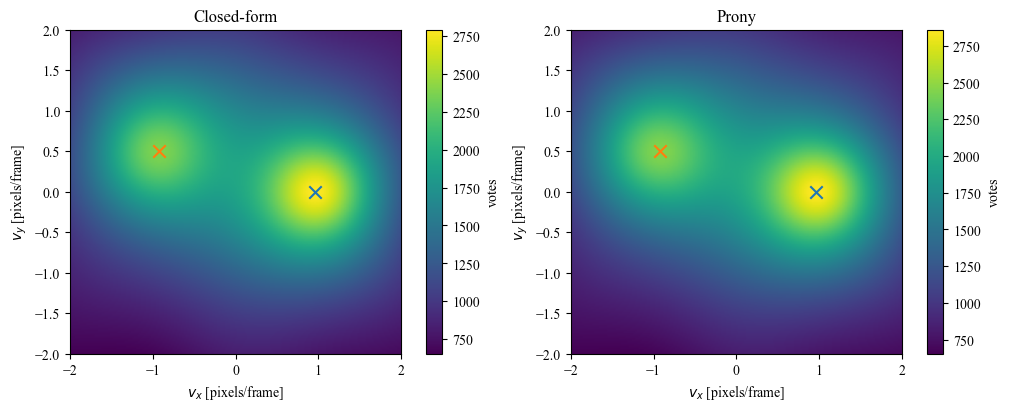

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for ax, res, title in zip(
    axs,
    [res_closed, res_prony],
    ["Closed-form", "Prony"],
):
    im = ax.imshow(
        res.hough,
        origin="lower",
        extent=[
            res.vx_values[0],
            res.vx_values[-1],
            res.vy_values[0],
            res.vy_values[-1],
        ],
        aspect="auto",
    )

    ax.set_title(title)
    ax.set_xlabel(r"$v_x$ [pixels/frame]")
    ax.set_ylabel(r"$v_y$ [pixels/frame]")

    # Optional: mark detected velocities
    for vx, vy in res.velocities:
        ax.scatter(vx, vy, marker="x", s=80)

    fig.colorbar(im, ax=ax, label="votes")

plt.show()

In [10]:
noise_levels = np.linspace(0, 0.2, 10)
errors = []

gt = np.array(meta["velocities"])

for sigma in noise_levels:
    video, _, _ = generate_synthetic_sequence(
        T=6, H=64, W=64,
        objects=objects,
        noise_std=sigma,
        clip=False,
        seed=0,
    )

    res = FourierVisionSegmenter(cfg_prony).detect(video)

    est = np.array(res.velocities)

    dists = [
        min(np.linalg.norm(e - g) for e in est)
        for g in gt
    ]
    errors.append(np.mean(dists))

Text(0.5, 1.0, 'Noise robustness')

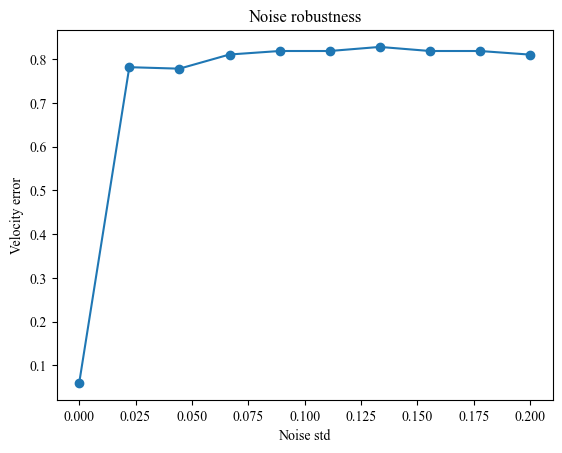

In [11]:
plt.plot(noise_levels, errors, '-o')
plt.xlabel("Noise std")
plt.ylabel("Velocity error")
plt.title("Noise robustness")

In [15]:
objects3 = [
    MovingObject("gaussian", (16, 16), (0.5, 0.0), 4.0),
    MovingObject("gaussian", (48, 16), (-0.5, 0.5), 4.0),
    MovingObject("gaussian", (32, 48), (0.25, -0.5), 5.0),
]

video3, _, meta3 = generate_synthetic_sequence(
    T=8, H=64, W=64,
    objects=objects3,
    noise_std=0.0,
    clip=False,
)

cfg3 = FourierVisionConfig(
    velocity_bounds=[-1,1],
    peak_min_separation=25,
    solver="prony",
    num_components=3,
    num_velocities=3,
    hough_sigma=0.05
)

res3 = FourierVisionSegmenter(cfg3).detect(video3)

print("GT:", meta3["velocities"])
print("Estimated:", res3.velocities)

GT: [(0.5, 0.0), (-0.5, 0.5), (0.25, -0.5)]
Estimated: [(0.49, -0.020000000000000018), (0.27, -0.49), (-0.5, 0.5)]


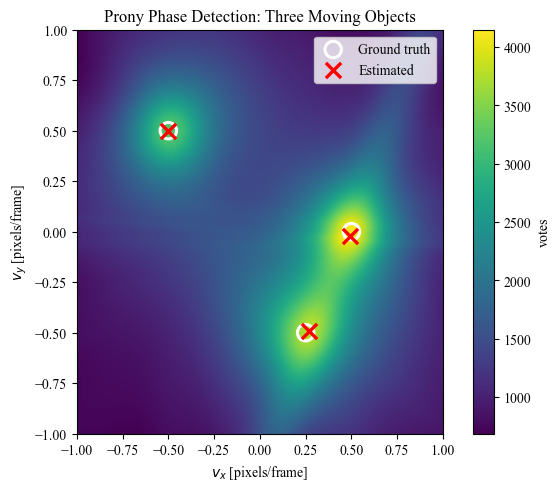

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.8), constrained_layout=True)

im = ax.imshow(
    res3.hough,
    origin="lower",
    extent=[
        res3.vx_values[0],
        res3.vx_values[-1],
        res3.vy_values[0],
        res3.vy_values[-1],
    ],
    aspect="auto",
)

# Ground-truth velocities: white circles
for vx, vy in meta3["velocities"]:
    ax.scatter(
        vx,
        vy,
        marker="o",
        s=140,
        facecolors="none",
        edgecolors="white",
        linewidths=2.2,
        label="Ground truth",
    )

# Estimated velocities: red crosses
for vx, vy in res3.velocities:
    ax.scatter(
        vx,
        vy,
        marker="x",
        s=120,
        linewidths=2.4,
        color="red",
        label="Estimated",
    )

ax.set_title("Prony Phase Detection: Three Moving Objects")
ax.set_xlabel(r"$v_x$ [pixels/frame]")
ax.set_ylabel(r"$v_y$ [pixels/frame]")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("votes")

# Avoid duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right", frameon=True)

plt.show()